In [2]:
# Установка в Jupyter:
import sys
!{sys.executable} -m pip install tensorflow


In [4]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import img_to_array, load_img
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


In [98]:
import pandas as pd

df = pd.read_csv('/Users/adiletkanatbek/Downloads/full_df.csv')

df['filepath'] = df['filepath'].apply(lambda x: x.replace('ODIR/training', '/Users/adiletkanatbek/Downloads/preprocessed_images'))

df.head()


,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,Left-Diagnostic Keywords,Right-Diagnostic Keywords,N,D,G,C,A,H,M,O,filepath,labels,target,filename
0,0,69,Female,0_left.jpg,0_right.jpg,cataract,normal fundus,0,0,0,1,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",0_right.jpg
1,1,57,Male,1_left.jpg,1_right.jpg,normal fundus,normal fundus,1,0,0,0,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",1_right.jpg
2,2,42,Male,2_left.jpg,2_right.jpg,laser spot，moderate non proliferative retinopathy,moderate non proliferative retinopathy,0,1,0,0,0,0,0,1,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",2_right.jpg
3,4,53,Male,4_left.jpg,4_right.jpg,macular epiretinal membrane,mild nonproliferative retinopathy,0,1,0,0,0,0,0,1,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",4_right.jpg
4,5,50,Female,5_left.jpg,5_right.jpg,moderate non proliferative retinopathy,moderate non proliferative retinopathy,0,1,0,0,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",5_right.jpg


In [94]:
import os
from tensorflow.keras.preprocessing import image
import numpy as np

X = []
y = []

df['filepath'] = df['filepath'].apply(lambda x: x.replace('../input/ocular-disease-recognition-odir5k/ODIR-5K/Training Images', '/Users/adiletkanatbek/Downloads/preprocessed_images'))

for idx, row in df.iterrows():
    img_path = row['filepath']
    if os.path.exists(img_path): 
        img = image.load_img(img_path, target_size=(224, 224)) 
        img = image.img_to_array(img) / 255.0  
        X.append(img)
        labels = [row['N'], row['D'], row['G'], row['C'], row['A'], row['H'], row['M'], row['O']]
        y.append(labels)
    else:
        print(f"Пропущено изображение: {img_path}")


X = np.array(X)
y = np.array(y)

print(f"Загружено изображений: {X.shape[0]}")


Загружено изображений: 6392


In [96]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Обучающее количество данных: {X_train.shape[0]}")
print(f"Тестовое количество данных: {X_test.shape[0]}")


Обучающее количество данных: 5113
Тестовое количество данных: 1279


In [92]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam

model = Sequential()

model.add(Input(shape=(224, 224, 3)))  

model.add(Conv2D(32, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))  
model.add(Dense(8, activation='sigmoid'))  


model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])


model.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,992 (42.61 MB)

 Trainable params: 11,169,992 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 123ms/step


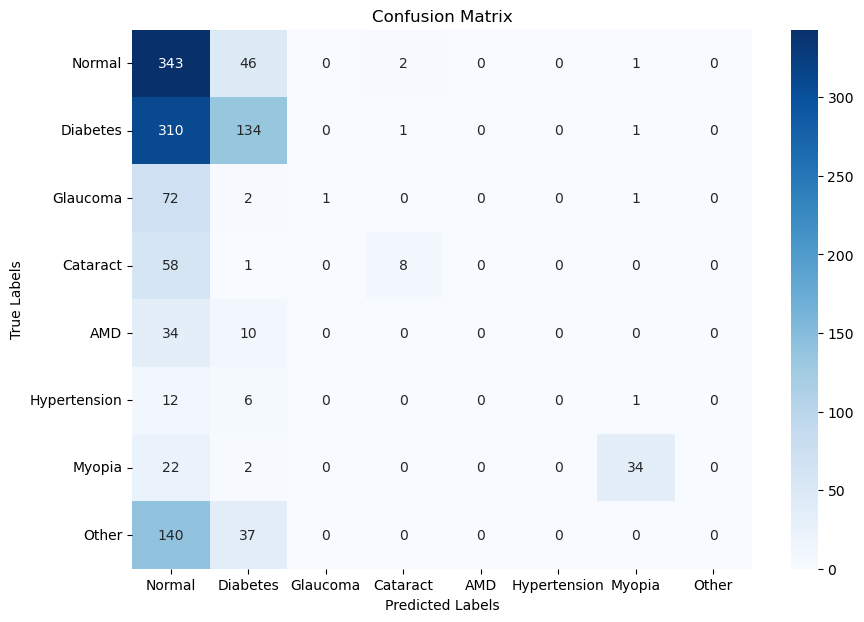

In [90]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)  


cm = confusion_matrix(y_test.argmax(axis=1), y_pred.argmax(axis=1))  

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=disease_classes, yticklabels=disease_classes)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()


In [64]:
from tensorflow.keras.callbacks import EarlyStopping

# Early stopping для предотвращения переобучения
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Обучаем модель
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop]  # Останавливаем обучение, если модель не улучшает метрики
)


Epoch 1/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 84s 509ms/step - accuracy: 0.3034 - loss: 0.4156 - val_accuracy: 0.4152 - val_loss: 0.3532
Epoch 2/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 80s 496ms/step - accuracy: 0.3297 - loss: 0.3645 - val_accuracy: 0.3636 - val_loss: 0.3524
Epoch 3/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 76s 476ms/step - accuracy: 0.3425 - loss: 0.3585 - val_accuracy: 0.3933 - val_loss: 0.3445
Epoch 4/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 76s 472ms/step - accuracy: 0.3689 - loss: 0.3469 - val_accuracy: 0.4238 - val_loss: 0.3391
Epoch 5/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 82s 512ms/step - accuracy: 0.3989 - loss: 0.3450 - val_accuracy: 0.4159 - val_loss: 0.3392
Epoch 6/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 80s 500ms/step - accuracy: 0.4085 - loss: 0.3376 - val_accuracy: 0.4261 - val_loss: 0.3367
Epoch 7/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 77s 480ms/step - accuracy: 0.4042 - loss: 0.3363 - val_accuracy: 0.4199 - val_loss: 0.3342
Epoch 8/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 75s 469ms/step - accuracy: 0.4243 - loss: 0

In [74]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int) 

disease_classes = ['Normal', 'Diabetes', 'Glaucoma', 'Cataract', 'AMD', 'Hypertension', 'Myopia', 'Other']

report = classification_report(y_test, y_pred, target_names=disease_classes, output_dict=True, zero_division=1)
df_report = pd.DataFrame(report).transpose()
df_report[['precision', 'recall', 'f1-score']] = df_report[['precision', 'recall', 'f1-score']] * 100
df_report = df_report.round(2)

print("📊 Classification Report (%):\n")
print(df_report[['precision', 'recall', 'f1-score']])

roc_auc = roc_auc_score(y_test, y_pred, average='macro')
print(f"\n🏆 ROC-AUC Score (macro average): {roc_auc:.4f}")


40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 122ms/step
📊 Classification Report (%):

              precision  recall  f1-score
Normal            53.00   13.52     21.54
Diabetes          56.30   30.04     39.18
Glaucoma         100.00    1.19      2.35
Cataract          81.82   10.98     19.35
AMD              100.00    0.00      0.00
Hypertension     100.00    0.00      0.00
Myopia            92.11   52.24     66.67
Other            100.00    0.00      0.00
micro avg         59.79   15.45     24.55
macro avg         85.40   13.50     18.64
weighted avg      73.41   15.45     21.42
samples avg       87.80   16.00     16.71

🏆 ROC-AUC Score (macro average): 0.5561


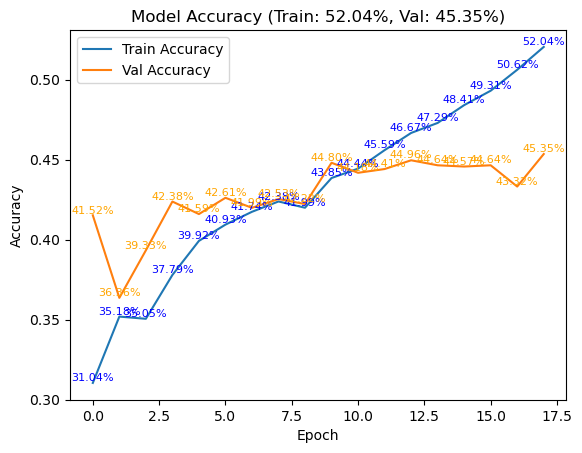

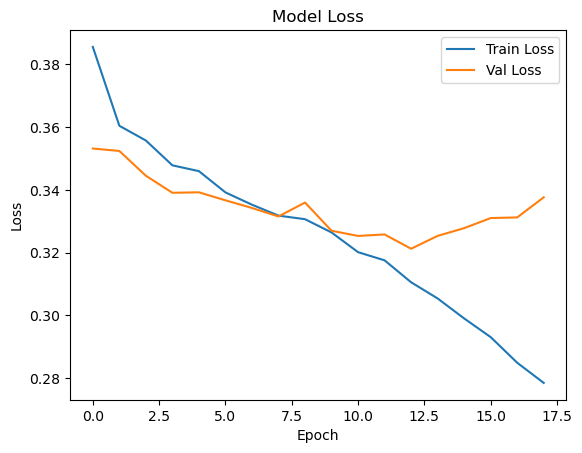

In [76]:
import matplotlib.pyplot as plt

train_accuracy = history.history['accuracy'][-1] * 100  # Последнее значение для тренировки
val_accuracy = history.history['val_accuracy'][-1] * 100  # Последнее значение для валидации

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title(f'Model Accuracy (Train: {train_accuracy:.2f}%, Val: {val_accuracy:.2f}%)')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

for i in range(len(history.history['accuracy'])):
    plt.text(i, history.history['accuracy'][i], f"{history.history['accuracy'][i]*100:.2f}%", ha='center', va='bottom', fontsize=8, color='blue')
    plt.text(i, history.history['val_accuracy'][i], f"{history.history['val_accuracy'][i]*100:.2f}%", ha='center', va='bottom', fontsize=8, color='orange')

plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show() 
